In [ ]:
# THIS IS A GOOGLE COLAB NOTEBOOK. CODE WILL NEED CHANGES IF RUNNING LOCALLY


# Video Model Build and Training script

In [ ]:
!pip install tensorflow scikit-learn matplotlib pandas numpy

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        print("GPU memory growth could not be set:", e)
else:
    print("No GPU detected. Training will run on CPU.")

TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PREPARED_OUTPUT_DIR = Path("/content/drive/MyDrive/datasets/demo5/prepared_lstm_data")
MODEL_OUTPUT_DIR = Path("/content/drive/MyDrive/datasets/demo5/trained_video_model")

MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [ ]:
X_train = np.load(PREPARED_OUTPUT_DIR / "X_train.npy")
y_train = np.load(PREPARED_OUTPUT_DIR / "y_train.npy")

X_val = np.load(PREPARED_OUTPUT_DIR / "X_val.npy")
y_val = np.load(PREPARED_OUTPUT_DIR / "y_val.npy")

X_test = np.load(PREPARED_OUTPUT_DIR / "X_test.npy")
y_test = np.load(PREPARED_OUTPUT_DIR / "y_test.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (837, 25, 1434)
y_train: (837,)
X_val: (138, 25, 1434)
y_val: (138,)
X_test: (183, 25, 1434)
y_test: (183,)


In [ ]:
with open(PREPARED_OUTPUT_DIR / "preprocessing_config.json", "r") as f:
    config = json.load(f)

config

{'target_fps': 5,
 'window_size': 25,
 'stride': 10,
 'feature_dim': 1434,
 'label_mapping': {'truthful': 0, 'deceptive': 1},
 'split': {'train': 79, 'validation': 17, 'test': 17}}

In [ ]:
WINDOW_SIZE = config["window_size"]
FEATURE_DIM = config["feature_dim"]

print("Window size:", WINDOW_SIZE)
print("Feature dimension:", FEATURE_DIM)

Window size: 25
Feature dimension: 1434


In [ ]:
print("Train label distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation label distribution:")
print(pd.Series(y_val).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Train label distribution:
0.0    486
1.0    351
Name: count, dtype: int64

Validation label distribution:
1.0    71
0.0    67
Name: count, dtype: int64

Test label distribution:
0.0    106
1.0     77
Name: count, dtype: int64


In [ ]:
def build_bilstm_video_model(window_size, feature_dim):
    model = models.Sequential([
        layers.Input(shape=(window_size, feature_dim)),

        layers.Bidirectional(
            layers.LSTM(64, return_sequences=True)
        ),
        layers.Dropout(0.3),

        layers.Bidirectional(
            layers.LSTM(32)
        ),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [ ]:
model = build_bilstm_video_model(
    window_size=WINDOW_SIZE,
    feature_dim=FEATURE_DIM
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │       767,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 812,929 (3.10 MB)

 Trainable params: 812,929 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_path = MODEL_OUTPUT_DIR / "best_video_bilstm_model.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
49/53 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6325 - auc: 0.6214 - loss: 0.6540
Epoch 1: val_loss improved from None to 0.47437, saving model to /content/drive/MyDrive/datasets/demo5/trained_video_model/best_video_bilstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets/demo5/trained_video_model/best_video_bilstm_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6834 - auc: 0.6954 - loss: 0.6151 - val_accuracy: 0.8188 - val_auc: 0.8047 - val_loss: 0.4744 - learning_rate: 5.0000e-04
Epoch 2/50
50/53 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7492 - auc: 0.7537 - loss: 0.5546
Epoch 2: val_loss did not improve from 0.47437
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7384 - auc: 0.7464 - loss: 0.5630 - val_accuracy: 0.7609 - val_auc: 0.7814 - val_loss: 0.4760 - learning_rate: 5.0000e-04
Epoch 3/50
51/53 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7411 - auc: 0.7123 - loss: 0.5858
Epoch 3: val_loss did not i

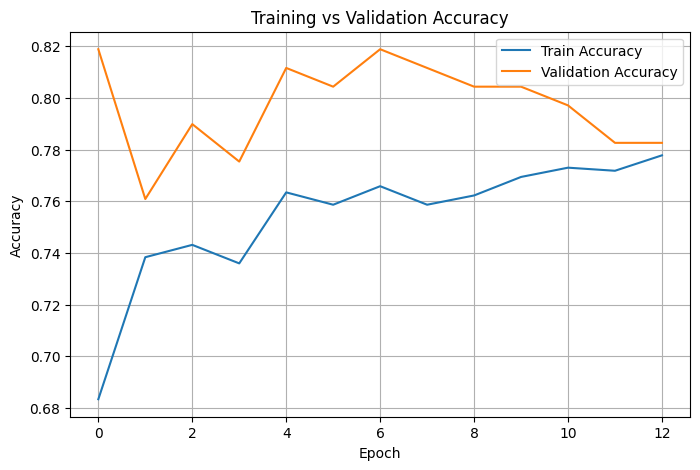

In [ ]:
# Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

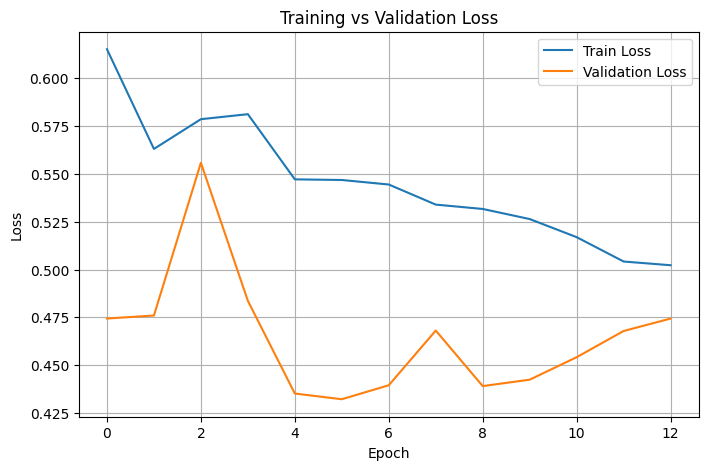

In [ ]:
# Training Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

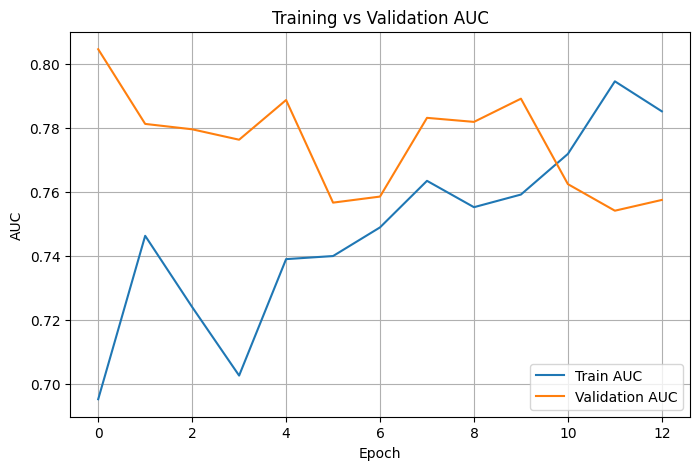

In [ ]:
# Training AUC
plt.figure(figsize=(8, 5))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training vs Validation AUC")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_model = tf.keras.models.load_model(MODEL_OUTPUT_DIR / "best_video_bilstm_model.keras")

In [ ]:
test_loss, test_accuracy, test_auc = best_model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test AUC:", test_auc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7705 - auc: 0.7384 - loss: 0.5030
Test Loss: 0.5029586553573608
Test Accuracy: 0.7704917788505554
Test AUC: 0.7384219169616699


In [ ]:
y_prob = best_model.predict(X_test).ravel()

y_pred = (y_prob >= 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC:", auc)

Accuracy: 0.7704918032786885
Precision: 1.0
Recall: 0.45454545454545453
F1-score: 0.625
AUC: 0.722249448664543


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Truthful", "Deceptive"],
    zero_division=0
))

              precision    recall  f1-score   support

    Truthful       0.72      1.00      0.83       106
   Deceptive       1.00      0.45      0.62        77

    accuracy                           0.77       183
   macro avg       0.86      0.73      0.73       183
weighted avg       0.84      0.77      0.75       183



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[106   0]
 [ 42  35]]


In [ ]:
final_model_path = MODEL_OUTPUT_DIR / "final_video_bilstm_model.keras"
best_model.save(final_model_path)

print("Final model saved to:", final_model_path)

Final model saved to: /content/drive/MyDrive/datasets/demo5/trained_video_model/final_video_bilstm_model.keras


In [ ]:
metrics = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_auc": float(test_auc),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "auc": float(auc),
    "threshold": 0.5
}

with open(MODEL_OUTPUT_DIR / "video_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

metrics

{'test_loss': 0.5029586553573608,
 'test_accuracy': 0.7704917788505554,
 'test_auc': 0.7384219169616699,
 'accuracy': 0.7704918032786885,
 'precision': 1.0,
 'recall': 0.45454545454545453,
 'f1_score': 0.625,
 'auc': 0.722249448664543,
 'threshold': 0.5}

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(MODEL_OUTPUT_DIR / "training_history.csv", index=False)

history_df.head()

,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate
0,0.683393,0.695356,0.615131,0.818841,0.804709,0.474374,0.00050
1,0.738351,0.746412,0.563015,0.760870,0.781375,0.475956,0.00050
2,0.743130,0.724163,0.578567,0.789855,0.779693,0.555787,0.00050
3,0.735962,0.702745,0.581180,0.775362,0.776435,0.483615,0.00050
4,0.763441,0.739126,0.547118,0.811594,0.788837,0.435177,0.00025
